In [2]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Load the synthetic dataset
df = pd.read_csv("../data/synthetic_pos.csv")

# Convert date columns to proper datetime type
df["po_date"] = pd.to_datetime(df["po_date"])
df["delivery_date"] = pd.to_datetime(df["delivery_date"])

print(f"Loaded {len(df):,} rows × {len(df.columns)} columns")

Loaded 5,000 rows × 20 columns


In [3]:
# Sanity check — what does our data actually look like?
print("=== First 3 rows ===")
display(df.head(3))

print("\n=== Column data types ===")
df.info()

=== First 3 rows ===


,po_id,po_date,vendor_id,vendor_cluster,vendor_is_new,vendor_reliability,fabric_type,garment_category,order_qty,destination_city,destination_tier,payment_mode,season,planned_lead_time_days,actual_lead_time_days,delivery_date,delay_days,is_delayed,return_probability,is_returned
0,PO001465,2025-04-01,V05,Bengaluru,False,0.93,knit,t-shirt,263,Jaipur,Tier-2,COD,normal,22,22,2025-04-23,0,False,0.275,True
1,PO000029,2025-04-01,V02,Tirupur,False,0.88,woven,overshirt,129,Kolkata,Tier-1,Prepaid,normal,34,37,2025-05-08,3,False,0.220,False
2,PO004545,2025-04-01,V04,Tirupur,False,0.90,knit,sweatshirt,60,Bengaluru,Tier-1,Prepaid,normal,21,21,2025-04-22,0,False,0.220,True



=== Column data types ===
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   po_id                   5000 non-null   str           
 1   po_date                 5000 non-null   datetime64[us]
 2   vendor_id               5000 non-null   str           
 3   vendor_cluster          5000 non-null   str           
 4   vendor_is_new           5000 non-null   bool          
 5   vendor_reliability      5000 non-null   float64       
 6   fabric_type             5000 non-null   str           
 7   garment_category        5000 non-null   str           
 8   order_qty               5000 non-null   int64         
 9   destination_city        5000 non-null   str           
 10  destination_tier        5000 non-null   str           
 11  payment_mode            5000 non-null   str           
 12  season                  5000 non

In [4]:
# Verify the data actually shows the patterns we calibrated for
print("=== Vendor concentration (top-3 should be ~60%) ===")
vendor_share = df["vendor_id"].value_counts(normalize=True).head(3)
print(vendor_share.apply(lambda x: f"{x:.1%}"))
print(f"Top-3 total: {vendor_share.sum():.1%}\n")

print("=== Tier mix (Unicommerce says 66% non-metro) ===")
print(df["destination_tier"].value_counts(normalize=True).apply(lambda x: f"{x:.1%}"), "\n")

print("=== Payment mix (D2C value tier: 60/40 COD/Prepaid) ===")
print(df["payment_mode"].value_counts(normalize=True).apply(lambda x: f"{x:.1%}"), "\n")

print("=== Fabric mix (Snitch knit-heavy: 75/25) ===")
print(df["fabric_type"].value_counts(normalize=True).apply(lambda x: f"{x:.1%}"), "\n")

print("=== Season distribution ===")
print(df["season"].value_counts(normalize=True).apply(lambda x: f"{x:.1%}"))

=== Vendor concentration (top-3 should be ~60%) ===
vendor_id
V01    25.1%
V02    18.3%
V05    16.3%
Name: proportion, dtype: str
Top-3 total: 59.7%

=== Tier mix (Unicommerce says 66% non-metro) ===
destination_tier
Tier-2    36.3%
Tier-1    34.3%
Tier-3    29.4%
Name: proportion, dtype: str 

=== Payment mix (D2C value tier: 60/40 COD/Prepaid) ===
payment_mode
COD        58.2%
Prepaid    41.8%
Name: proportion, dtype: str 

=== Fabric mix (Snitch knit-heavy: 75/25) ===
fabric_type
knit     72.7%
woven    27.3%
Name: proportion, dtype: str 

=== Season distribution ===
season
normal     43.5%
festive    33.6%
monsoon    22.9%
Name: proportion, dtype: str


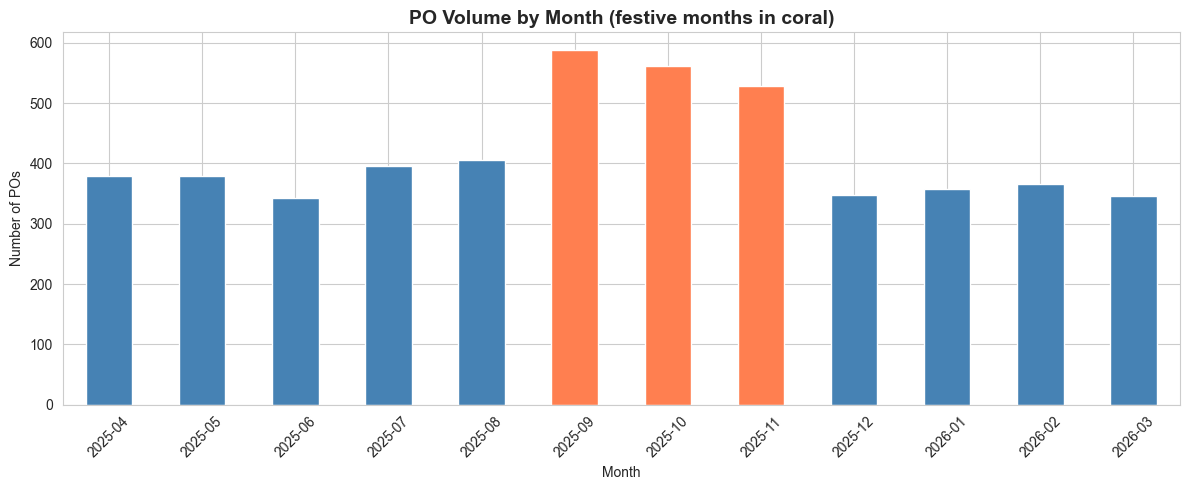

Festive months (Sep-Nov) avg: 559 POs/month
Normal months avg:           363 POs/month
Festive uplift: 1.54x


In [5]:
# Chart 1: Order volume by month — festive months (Sep-Nov) should be visibly higher
monthly_volume = df.groupby(df["po_date"].dt.to_period("M")).size()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["coral" if m.month in [9, 10, 11] else "steelblue" for m in monthly_volume.index]
monthly_volume.plot(kind="bar", ax=ax, color=colors, edgecolor="white")

ax.set_title("PO Volume by Month (festive months in coral)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of POs")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

festive_total = monthly_volume[monthly_volume.index.month.isin([9, 10, 11])].sum()
normal_avg = monthly_volume[~monthly_volume.index.month.isin([9, 10, 11, 6, 7, 8])].mean()
print(f"Festive months (Sep-Nov) avg: {monthly_volume[monthly_volume.index.month.isin([9, 10, 11])].mean():.0f} POs/month")
print(f"Normal months avg:           {normal_avg:.0f} POs/month")
print(f"Festive uplift: {monthly_volume[monthly_volume.index.month.isin([9, 10, 11])].mean() / normal_avg:.2f}x")

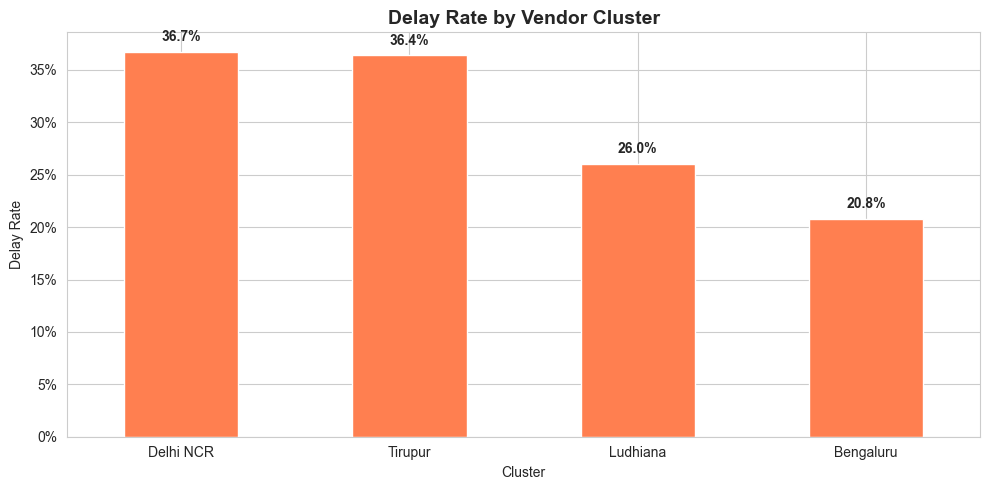


Cluster delay rates (sorted):
vendor_cluster
Delhi NCR    36.7%
Tirupur      36.4%
Ludhiana     26.0%
Bengaluru    20.8%
Name: is_delayed, dtype: str


In [6]:
# Chart 2: Delay rate by cluster — Tirupur should be worst (95% capacity utilization per benchmarks §5)
delay_by_cluster = df.groupby("vendor_cluster")["is_delayed"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
delay_by_cluster.plot(kind="bar", ax=ax, color="coral", edgecolor="white")

ax.set_title("Delay Rate by Vendor Cluster", fontsize=14, fontweight="bold")
ax.set_xlabel("Cluster")
ax.set_ylabel("Delay Rate")
ax.tick_params(axis="x", rotation=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

# Add value labels on top of each bar
for i, v in enumerate(delay_by_cluster):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print("\nCluster delay rates (sorted):")
print(delay_by_cluster.apply(lambda x: f"{x:.1%}"))

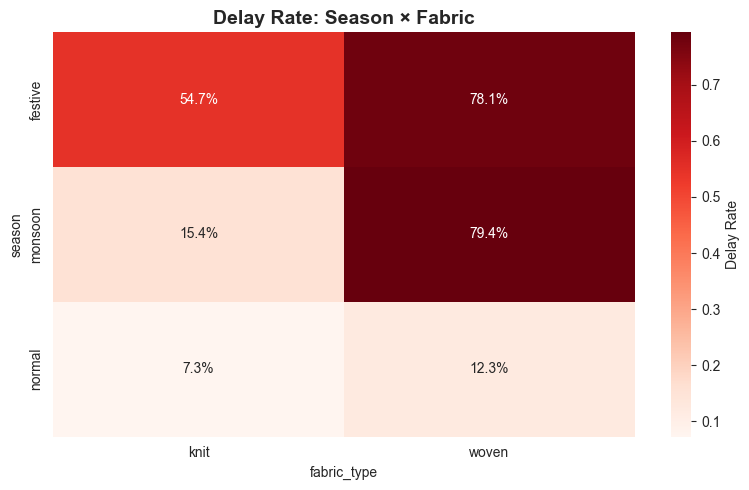

In [7]:
# Chart 3: Delay rate by season × fabric — festive and monsoon should be visible
pivot_delay = df.pivot_table(
    index="season",
    columns="fabric_type",
    values="is_delayed",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_delay, annot=True, fmt=".1%", cmap="Reds", ax=ax,
            cbar_kws={"label": "Delay Rate"})
ax.set_title("Delay Rate: Season × Fabric", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()# Chart 4: Return rate by payment × tier — COD and Tier-3 amplifiers should both show


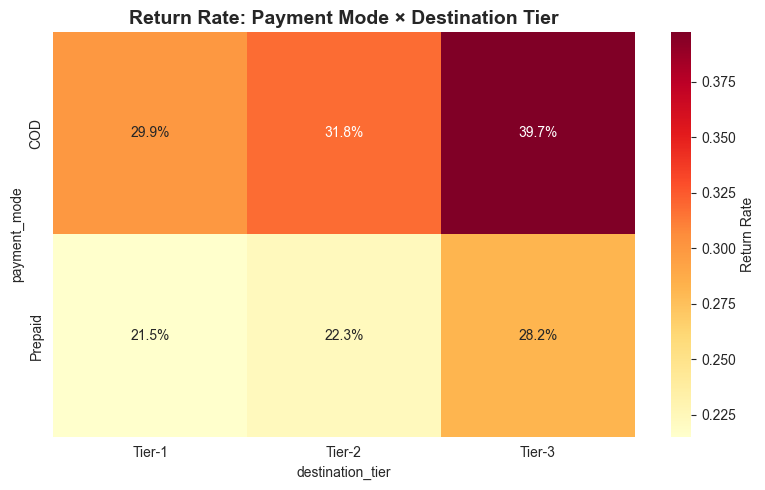

In [8]:
pivot_returns = df.pivot_table(
    index="payment_mode",
    columns="destination_tier",
    values="is_returned",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_returns, annot=True, fmt=".1%", cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "Return Rate"})
ax.set_title("Return Rate: Payment Mode × Destination Tier", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

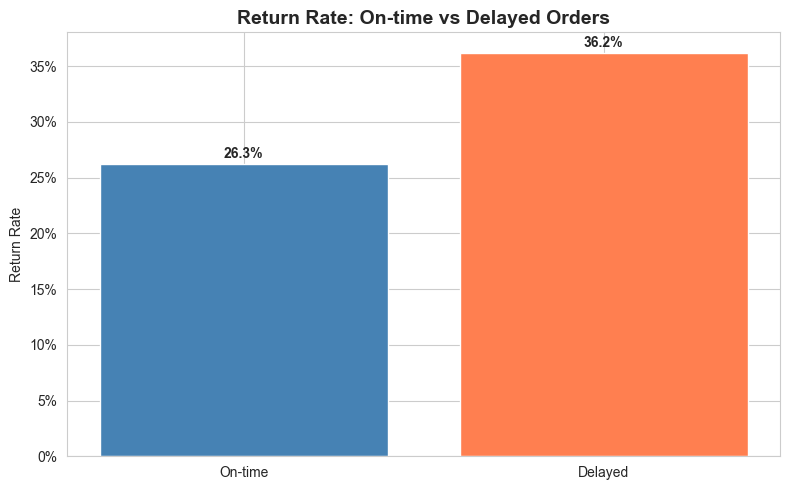

On-time return rate:  26.3%
Delayed return rate:  36.2%
Delay → return uplift: 1.38x


In [9]:
# Chart 5: Do delayed orders return more? (Validates a key model assumption)
return_by_delay = df.groupby("is_delayed")["is_returned"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(["On-time", "Delayed"], return_by_delay.values,
              color=["steelblue", "coral"], edgecolor="white")
ax.set_title("Return Rate: On-time vs Delayed Orders", fontsize=14, fontweight="bold")
ax.set_ylabel("Return Rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

for bar, value in zip(bars, return_by_delay.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.005,
            f"{value:.1%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

uplift = return_by_delay[True] / return_by_delay[False]
print(f"On-time return rate:  {return_by_delay[False]:.1%}")
print(f"Delayed return rate:  {return_by_delay[True]:.1%}")
print(f"Delay → return uplift: {uplift:.2f}x")

In [10]:
# Chart 6: Vendor scorecard — all 12 vendors with delay + return metrics, color-graded
vendor_scorecard = df.groupby("vendor_id").agg(
    orders=("po_id", "count"),
    cluster=("vendor_cluster", "first"),
    is_new=("vendor_is_new", "first"),
    delay_rate=("is_delayed", "mean"),
    return_rate=("is_returned", "mean"),
    avg_delay_days=("delay_days", "mean"),
).sort_values("delay_rate", ascending=False).round(3)

# Format and color-grade for visual scanning
display(
    vendor_scorecard.style
    .format({"delay_rate": "{:.1%}", "return_rate": "{:.1%}", "avg_delay_days": "{:.1f}"})
    .background_gradient(subset=["delay_rate", "return_rate"], cmap="Reds")
)

,orders,cluster,is_new,delay_rate,return_rate,avg_delay_days
vendor_id,,,,,,
V11,42,Tirupur,True,92.9%,38.1%,12.0
V12,47,Bengaluru,True,87.2%,44.7%,11.2
V03,390,Tirupur,False,39.2%,32.8%,4.9
V10,154,Delhi NCR,False,37.7%,26.6%,3.9
V04,369,Tirupur,False,36.6%,27.1%,4.7
V09,227,Delhi NCR,False,36.1%,28.2%,3.4
V01,1255,Tirupur,False,35.0%,29.5%,4.5
V08,190,Ludhiana,False,34.7%,26.8%,3.3
V02,913,Tirupur,False,34.4%,30.8%,4.5
